# Resultados DiMMAD

Carga los 4 archivos `dataset/scheme` y grafica las curvas de pureza y diversidad en una sola figura.

In [1]:
from pathlib import Path
import pickle
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "dimmad_benchmark").exists() and (base / "settings.txt").exists():
            return base
        if (base / "sldnet" / "dimmad_benchmark").exists() and (base / "sldnet" / "settings.txt").exists():
            return base / "sldnet"
    raise FileNotFoundError("No pude encontrar la raiz de sldnet.")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dimmad_benchmark import run_experiments

sns.set_theme(style="whitegrid")
ROOT

/home/sguzman/miniconda3/envs/astro/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/home/sguzman/mgscode/thesis/sldnet')

In [ ]:
import matplotlib.font_manager as font_manager

font_path = ROOT / "font" / "cmunrm.ttf"
if font_path.exists():
    font_manager.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

RESULT_KEYS = [
    ("elasticc", "ood"),
    ("elasticc", "rid"),
    ("ztf", "ood"),
    ("ztf", "rid"),
]

COLUMN_RENAMES = {
    "score_DistClassiPy (min-median)": "score_DiMMAD (min-med)",
    "score_DistClassiPy (median-median)": "score_DiMMAD (med-med)",
    "score_IsolationForest": "score_iForest",
    "score_LocalOutlierFactor": "score_LOF",
    "score_OneClassSVM": "score_OC-SVM",
    "score_Autoencoder": "score_Autoencoder",
    "score_ClassSVDD": "score_MCSVDD",
}

MODEL_ORDER = [
    "SLDNet (L:4)",
    "SLDNet (L:0.001)",
    "DiMMAD (med-med)",
    "DiMMAD (min-med)",
    "iForest",
    "LOF",
    "OC-SVM",
    "Autoencoder",
    "MCSVDD",
]


def resolve_result_path(dataset, scheme):
    candidates = [
        ROOT / "results_paper" / "dimmad" / f"{dataset}_{scheme}_results.pkl",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"No encontre resultados para {dataset}/{scheme}.")


def load_results(dataset, scheme):
    result_path = resolve_result_path(dataset, scheme)
    with open(result_path, "rb") as f:
        all_run_results = pickle.load(f)

    all_run_results = [fold.rename(columns=COLUMN_RENAMES) for fold in all_run_results]
    available_models = {
        model_name: None
        for model_name in MODEL_ORDER
        if all(f"score_{model_name}" in fold.columns for fold in all_run_results)
    }

    return {
        "path": result_path,
        "results": all_run_results,
        "models": available_models,
    }


bundles = {
    (dataset, scheme): load_results(dataset, scheme)
    for dataset, scheme in RESULT_KEYS
}

for (dataset, scheme), bundle in bundles.items():
    print(
        f"{dataset}/{scheme}: {bundle['path'].relative_to(ROOT)} | "
        f"runs={len(bundle['results'])} | models={list(bundle['models'])}"
    )

elasticc/ood: results_paper/dimmad/elasticc_ood_results.pkl | runs=20 | models=['SLDNet (L:4)', 'SLDNet (L:0.001)', 'DiMMAD (med-med)', 'DiMMAD (min-med)', 'iForest', 'LOF', 'OC-SVM', 'Autoencoder', 'MCSVDD']
elasticc/rid: results_paper/dimmad/elasticc_rid_results.pkl | runs=20 | models=['SLDNet (L:4)', 'SLDNet (L:0.001)', 'DiMMAD (med-med)', 'DiMMAD (min-med)', 'iForest', 'LOF', 'OC-SVM', 'Autoencoder', 'MCSVDD']
ztf/ood: results_paper/dimmad/ztf_ood_results.pkl | runs=20 | models=['SLDNet (L:4)', 'SLDNet (L:0.001)', 'DiMMAD (med-med)', 'DiMMAD (min-med)', 'iForest', 'LOF', 'OC-SVM', 'Autoencoder', 'MCSVDD']
ztf/rid: results_paper/dimmad/ztf_rid_results.pkl | runs=20 | models=['SLDNet (L:4)', 'SLDNet (L:0.001)', 'DiMMAD (med-med)', 'DiMMAD (min-med)', 'iForest', 'LOF', 'OC-SVM', 'Autoencoder', 'MCSVDD']


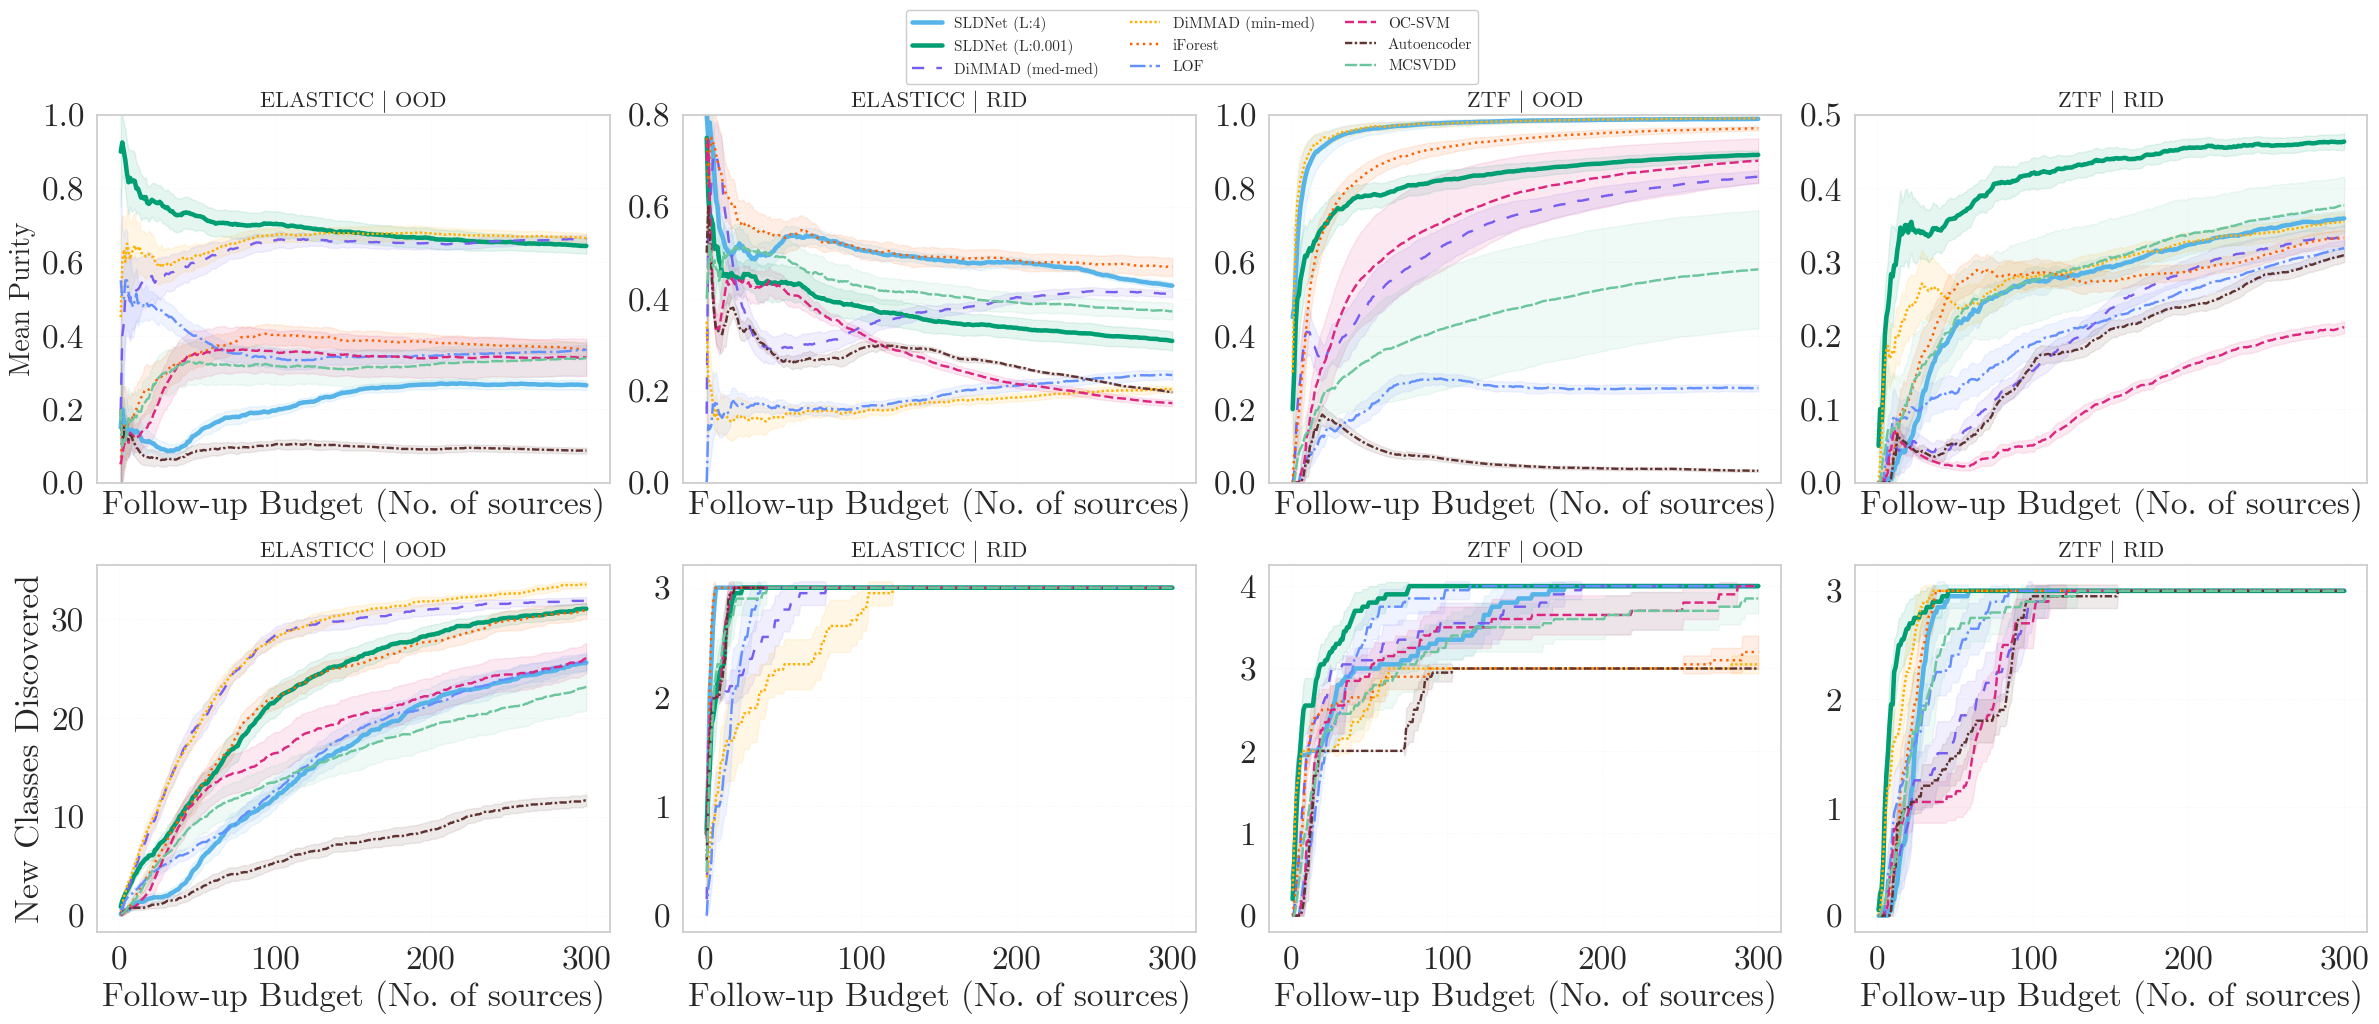

In [4]:
budget = 300
fig, axes = plt.subplots(2, len(RESULT_KEYS), figsize=(6 * len(RESULT_KEYS), 10), sharex=True)

for col, (dataset, scheme) in enumerate(RESULT_KEYS):
    bundle = bundles[(dataset, scheme)]
    title = f"{dataset.upper()} | {scheme.upper()}"

    for row, metric in enumerate(["purity", "diversity"]):
        ax = axes[row, col]
        plt.sca(ax)
        run_experiments.analysis_with_errors(
            bundle["models"],
            bundle["results"],
            budget=budget,
            metric=metric,
            show_legend=False,
        )
        ax.set_title(title, fontsize=16)
        ax.grid(True, alpha=0.25)

        if row == 0:
            purity_max = max((np.nanmax(line.get_ydata()) for line in ax.lines), default=0)
            ax.set_ylim(0, max(0.1, np.ceil(purity_max * 10) / 10))

        if col > 0:
            ax.set_ylabel("")

handles, labels = axes[0, 0].get_legend_handles_labels()
if not handles:
    for ax in axes.flat:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            break

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=min(3, len(labels)),
        framealpha=1.0,
        bbox_to_anchor=(0.5, 1.03),
    )

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()